In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import os
import tqdm

# 配置参数
domain_id_name_map = {
    "digitsdg": {0: 'MNIST', 1: 'MNIST-M', 2: 'SVHN', 3: 'SYN'},
    "officehome": {0: 'Art', 1: 'Clipart', 2: 'Product', 3: 'Real World'}
}

TSNE_PARAMS = {
    "n_components": 2,
    "perplexity": 30,
    "max_iter": 1000,
    "learning_rate": 200,
    "random_state": 42,
    "angle": 0.3
}

MARKER_CONFIG = {
    'real': {'marker': 'o', 's': 18, 'edgecolor': 'none', 'alpha': 0.8},
    'sampled': {'marker': 's', 's': 16, 'edgecolor': 'white',  'linewidth': 0.1, 'alpha':0.9},
    'generated': {'marker': 'd', 's': 18, 'edgecolor': 'black', 'linewidth': 0.1, 'alpha':0.9}
}

def main(data_folder, data_type="features"):
    # 创建保存目录
    save_dir = os.path.join(data_folder, f"{data_type}_tsne_analysis")
    os.makedirs(save_dir, exist_ok=True)
    
    # 加载数据
    real_data = np.load(os.path.join(data_folder, "real_features.npz"))
    sampled_data = np.load(os.path.join(data_folder, "sampled_features.npz"))
    generated_data = np.load(os.path.join(data_folder, "generated_features.npz"))
    
    # 获取数据集信息
    dataset = os.path.basename(data_folder).split('_')[0]
    num_domains = len(domain_id_name_map[dataset])
    num_classes = len(np.unique(np.concatenate([
        real_data['class_ids'], 
        sampled_data['class_ids'],
        generated_data['class_ids']
    ])))
    print(f"Dataset: {dataset}, #domains: {num_domains}, #classes: {num_classes}")
    print(f"Real data: {real_data[data_type].shape}\nSampled data: {sampled_data[data_type].shape}\nGenerated data: {generated_data[data_type].shape}")

    palette = sns.color_palette("deep", n_colors=num_domains)
    
    # 处理每个类别
    unique_classes = np.unique(np.concatenate([
        real_data['class_ids'], 
        sampled_data['class_ids'],
        generated_data['class_ids']
    ]))
    
    for cls in tqdm.tqdm(unique_classes, desc="Processing classes"):
        # 提取类别数据
        masks = {
            'real': real_data['class_ids'] == cls,
            'sampled': sampled_data['class_ids'] == cls,
            'generated': generated_data['class_ids'] == cls
        }
        
        # 合并特征并归一化
        features = np.concatenate([
            real_data[data_type][masks['real']],
            sampled_data[data_type][masks['sampled']],
            generated_data[data_type][masks['generated']]
        ])
        features = (features - features.mean(0)) / features.std(0)
        
        # t-SNE降维
        embed_path = os.path.join(save_dir, f"cls_{cls}_{data_type}_embed.npy")
        if os.path.exists(embed_path):
            embeddings = np.load(embed_path)
        else:
            embeddings = TSNE(**TSNE_PARAMS).fit_transform(features)
            np.save(embed_path, embeddings)
        
        # 可视化设置
        plt.figure(figsize=(2, 2))
        ax = plt.gca()
        start = 0
        
        # 绘制每种数据类型
        for dtype in ['real', 'sampled', 'generated']:
            end = start + np.sum(masks[dtype])
            if end <= start:  # 处理空数据
                continue
                
            domains = {
                'real': real_data['domain_ids'][masks['real']],
                'sampled': sampled_data['domain_ids'][masks['sampled']],
                'generated': generated_data['domain_ids'][masks['generated']]
            }[dtype]
            
            # 按domain分组绘制
            for domain in np.unique(domains):
                mask = (domains == domain)
                plt.scatter(
                    x=embeddings[start:end][mask, 0],
                    y=embeddings[start:end][mask, 1],
                    color=palette[domain],
                    **MARKER_CONFIG[dtype],
                )
            start = end
        
        # 美化图形
        # plt.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('gray')  # 灰色边框
            spine.set_linewidth(0.8)
        plt.tight_layout(pad=0)
        plt.tight_layout(pad=0)
        
        # 保存图片
        plt.savefig(
            os.path.join(save_dir, f"{dataset}_cls_{cls}_{data_type}.png"),
            dpi=600, 
            bbox_inches='tight',
            transparent=True
        )
        plt.close()

for data_path in ["../imgs/digitsdg_dot10"]: #, "../imgs/officehome_dot10"
    # main(data_path, data_type="features")
    main(data_path, data_type="projections")

Dataset: digitsdg, #domains: 4, #classes: 10
Real data: (2560, 512)
Sampled data: (640, 512)
Generated data: (640, 512)


Processing classes: 100%|██████████| 10/10 [00:06<00:00,  1.55it/s]


findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

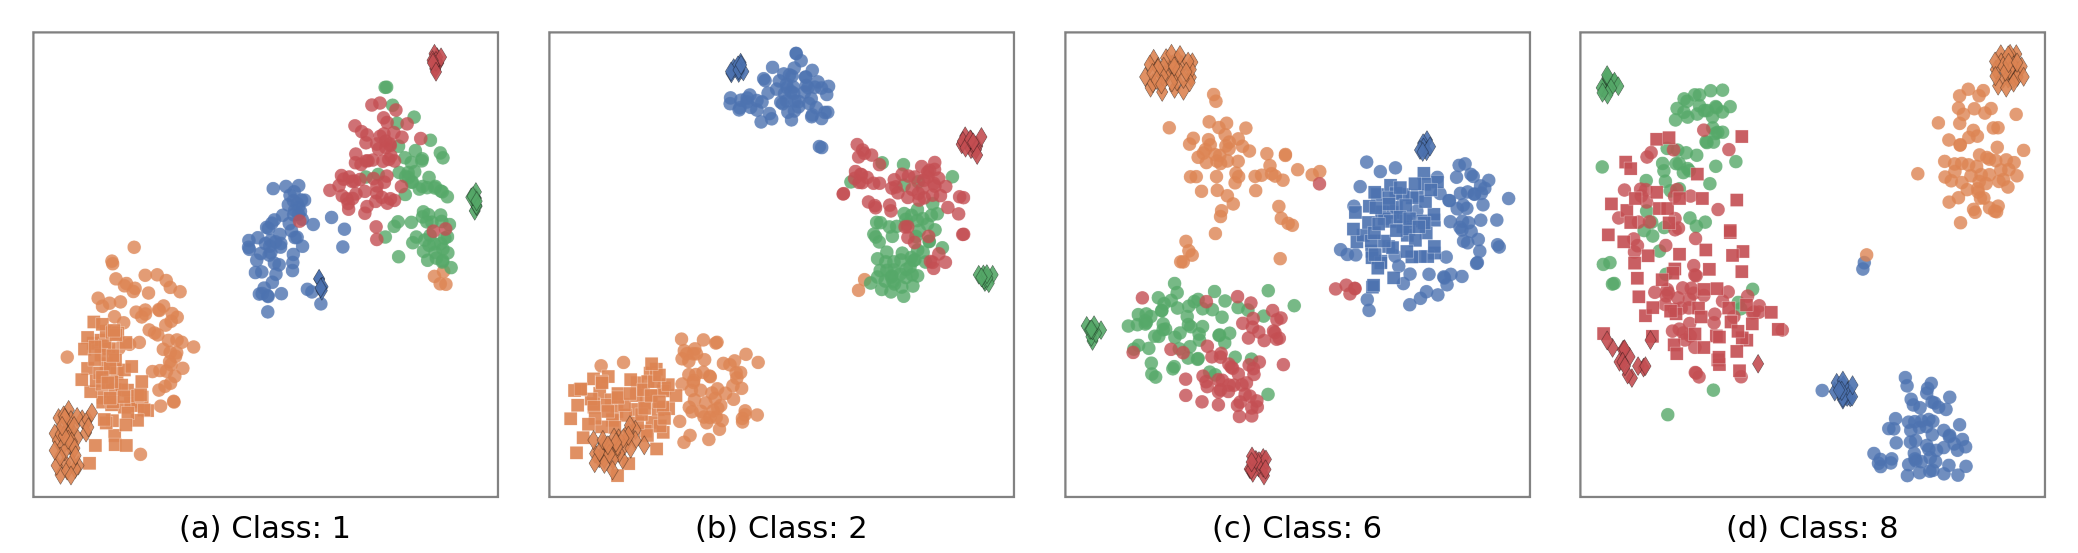

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image  # 用于读取图片文件
import numpy as np


img_folder = r"/gpfs-flash/junlab/liyuan/hongwei/DGIL/imgs"
digitsdg_imgs = [
    f"{img_folder}/digitsdg_dot10/projections_tsne_analysis/digitsdg_cls_1_projections.png",
    f"{img_folder}/digitsdg_dot10/projections_tsne_analysis/digitsdg_cls_3_projections.png",
    f"{img_folder}/digitsdg_dot10/projections_tsne_analysis/digitsdg_cls_6_projections.png",
    f"{img_folder}/digitsdg_dot10/projections_tsne_analysis/digitsdg_cls_8_projections.png",
]

# 设置全局字体参数（可根据需要修改）
plt.rcParams.update({
    # 'font.family': 'arial',  # 字体类型：serif, sans-serif, monospace等
    'font.size': 22,          # 基础字体大小
    'axes.titlesize': 22     # 子图标题字体大小
})

# 创建画布与子图布局 (2行4列)
fig, axs = plt.subplots(1, 4, figsize=(21, 6))
fig.subplots_adjust(
    wspace=0.01,   # 水平间距调整
    hspace=0.01,   # 垂直间距调整
    left=0.01,    # 左边距
    right=0.99,   # 右边距
    top=0.99,      # 顶部边距
    bottom=0.01    # 底部边距
)

image_paths = [ *digitsdg_imgs]

# 子图标题列表（按顺序填写8个标题）
titles = [
    "(a) Class: 1", "(b) Class: 2", "(c) Class: 6", "(d) Class: 8"
]

# ================= 图片读取与排版 =================
for idx, ax in enumerate(axs.flat):
    # 读取图片（如果PDF无法直接读取，需要先转换为PNG格式）
    try:
        img = Image.open(image_paths[idx])
    except:
        raise ValueError(f"无法读取图片：{image_paths[idx]}")

    # 显示图片
    ax.imshow(np.array(img))
    ax.axis('off')  # 关闭坐标轴
    
    ax.set_title(
        titles[idx],
        fontsize=22,            # 单独设置字体大小
        y = -0.05
        # fontweight='bold',    # 字体加粗（按需取消注释）
        # fontstyle='italic',   # 斜体（按需取消注释）
        # pad=12                  # 标题与图片的间距
    )

# 添加全局大标题（按需使用）
# plt.suptitle("Overall Figure Title", y=0.95, fontsize=14)

# 保存为PDF
plt.savefig(f"{img_folder}/digitsdg_dot10/projections_tsne_analysis/digits_generated_dot10_tsne.pdf", dpi=600, bbox_inches='tight', format='pdf')

In [ ]:
# data_folder = "../imgs/digitsdg_dot10"
# # data_folder = "../imgs/officehome_dot10"
# for root, dirs, files in os.walk(data_folder):
#     for file in files:
#         if file.endswith(".png"):
#             # remove it
#             os.remove(os.path.join(root, file))